<a href="https://colab.research.google.com/github/eg424/MIP/blob/Simulation/Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install magpylib

# Magnets setup

In [37]:
import magpylib as mp
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from scipy.spatial.transform import Rotation as R

# Select mode: 'single' (ball), 'chain', 'square' or 'ring' arragements
#mode = "single"
mode = "chain"
#mode = "square"
#mode = "ring"

# Neodymium - N40 Magnet Properties
magnet_properties = mp.magnet.Sphere(
    polarization=(0,0,1.24), # Z-axis. Retrieved from https://www.eclipsemagnetics.com/site/assets/files/19485/ndfeb_neodymium_iron_boron-standard_ndfeb_range_datasheet_rev1.pdf
    diameter=0.001, # 1mm
)
# Define positions based on arrangement:
if mode == "single":
  positions = [(0, 0, 0)]
elif mode == "chain":
  positions = [(0, 0, 0), (0.0016, 0, 0), (0.0046, 0, 0), (0.0076, 0, 0)]
  #positions = [(0, 0, 0), (0.0026, 0, 0), (0.0066, 0, 0), (0.0106, 0, 0)] # For plotting (2mm)
elif mode == "square":
  positions = [(0, 0, 0), (0.0016, 0, 0), (0, 0.0016, 0), (0.0016, 0.0016, 0)]
  #positions = [(0, 0, 0), (0.0026, 0, 0), (0, 0.0026, 0), (0.0026, 0.0026, 0)]
elif mode == "ring":
  r_ring = 0.0016  # 1.6 mm radius
  #r_ring = 0.0026
  angles_deg = np.arange(0,360,60)
  angles_rad = np.radians(angles_deg)

  positions = [
      (r_ring * np.cos(theta), r_ring * np.sin(theta), 0.0)
      for theta in angles_rad
      ]

# Generate rotation objects
rots = []
if mode == "chain":
  # Rotate polarization of all magnets to x-axis (90 deg)
  rots = [R.from_rotvec(np.radians([0, 90, 0]), degrees=False)] * len(positions)

elif mode == "square":
  rot_bl = R.from_euler('yx', [-45, -90], degrees=True) # Bottom Left
  rot_br = R.from_euler('yx', [-45, 90], degrees=True) # Bottom Right
  rot_tl = R.from_euler('yx', [45, -90], degrees=True) # Top Left
  rot_tr = R.from_euler('yx', [45, 90], degrees=True) # Top Right
  # Store in order of positions
  rots = [rot_bl, rot_br, rot_tl, rot_tr]

elif mode == "single":
  rots = [R.identity()] # No rotation

elif mode == "ring":
  # Rotate from Z to X
  base_rot = R.from_euler('x', -90, degrees=True)
  y_angles = [0, 60, 120, 180, 240, 300]

  rots = []
  for angle in y_angles:
      # Rotate around Z-axis to distribute around the ring
      ring_rot = R.from_euler('z', angle, degrees=True)
      # Final orientation: rotate dipole from Z to X, then spin around Z to point outward
      rot = ring_rot * base_rot
      rots.append(rot)

# Create spheres
spheres = []
for pos, Robj in zip(positions, rots):
    sph = magnet_properties.copy()
    sph.position = pos
    sph.orientation = Robj
    spheres.append(sph)

# Put them in a collection
magnets_collection = mp.Collection(*spheres)

# Create a sensor for measuring the field
sensor = mp.Sensor()

# Visualise arranged units
#mp.show(magnets_collection, sensor, backend = 'plotly')

# Simulations

## Interactions under no external MF





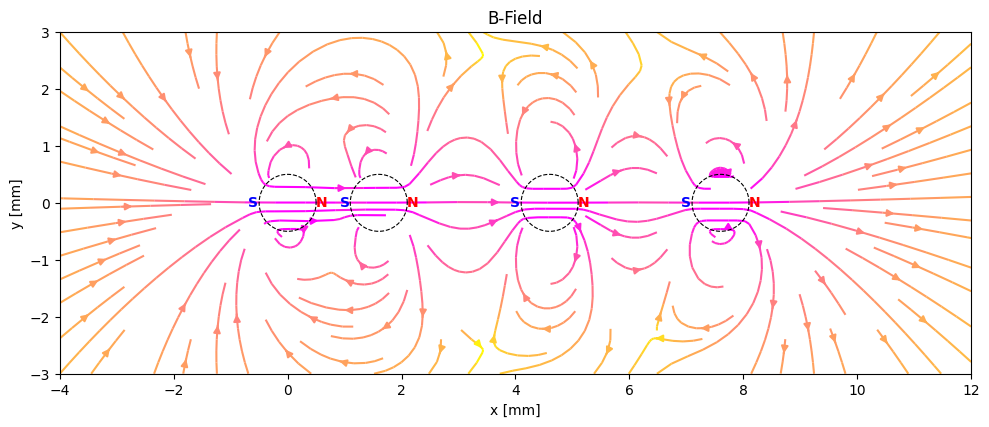

In [38]:
# Following guide on https://magpylib.readthedocs.io/en/stable/_pages/user_guide/examples/examples_tutorial_field_computation.html#examples-tutorial-field-computation-sensors

fig, ax = plt.subplots(figsize=(10, 10))

# Create a 2D grid (mm)
if mode == "single":
  # X-Z plane at Y=0
  x_vals = np.linspace(-0.003, 0.003, 100) * 1000
  z_vals = np.linspace(-0.003, 0.003, 200) * 1000
  xlim, ylim = (-3, 3), (-3, 3)
  X, Z = np.meshgrid(x_vals, z_vals)
  grid_points = np.zeros((X.size, 3))
  grid_points[:, 0] = (X.flatten() / 1000)
  grid_points[:, 2] = (Z.flatten() / 1000)

elif mode == "chain":
  # X-Y plane at Z=0
  x_vals = np.linspace(-0.004, 0.012, 100) * 1000
  y_vals = np.linspace(-0.003, 0.003, 100) * 1000
  xlim, ylim =(-4, 12), (-3, 3)
  X, Y = np.meshgrid(x_vals, y_vals)
  grid_points = np.zeros((X.size, 3))
  grid_points[:, 0] = (X.flatten() / 1000)
  grid_points[:, 1] = (Y.flatten() / 1000)
  grid_points[:, 2] = 0.0

elif mode == "square":
  # X-Y plane at Z=0
  x_vals = np.linspace(-0.003, 0.005, 100) * 1000
  y_vals = np.linspace(-0.003, 0.005, 100) * 1000
  xlim, ylim =(-3, 5),(-3, 5)
  X, Y = np.meshgrid(x_vals, y_vals)
  grid_points = np.zeros((X.size, 3))
  grid_points[:, 0] = (X.flatten() / 1000)
  grid_points[:, 1] = (Y.flatten() / 1000)
  grid_points[:, 2] = 0.0

elif mode == "ring":
  # X-Y plane at Z=0
  x_vals = np.linspace(-0.004, 0.004, 150) * 1000
  y_vals = np.linspace(-0.004, 0.004, 150) * 1000
  xlim, ylim =(-4, 4),(-4, 4)
  X, Y = np.meshgrid(x_vals, y_vals)
  grid_points = np.zeros((X.size, 3))
  grid_points[:, 0] = (X.flatten() / 1000)
  grid_points[:, 1] = (Y.flatten() / 1000)
  grid_points[:, 2] = 0.0


# Compute B-field
B = magnets_collection.getB(grid_points)

# Reshape for plotting
if mode == "single":
  Bx, Bz = B[:, 0].reshape(X.shape), B[:, 2].reshape(X.shape)
  Bmag = np.clip(norm(B[:, [0, 2]], axis=1).reshape(X.shape), 1e-12, None)
  ax.streamplot(X, Z, Bx, Bz, color=np.log(Bmag), cmap="spring_r")

else:
  Bx, By = B[:, 0].reshape(X.shape), B[:, 1].reshape(X.shape)
  Bmag = np.clip(norm(B[:, [0, 1]], axis=1).reshape(X.shape), 1e-12, None)
  ax.streamplot(X, Y, Bx, By, color=np.log(Bmag), cmap="spring_r")

title = "B-Field"
ax.set_title(title)
ax.set_xlabel("x [mm]")

if mode == "single":
    ax.set_ylabel("z [mm]")
else:
    ax.set_ylabel("y [mm]")

ax.set_aspect("equal")
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Add sphere outlines and N/S markers
for s in spheres:
    radius = 0.5
    center_mm = np.array(s.position) * 1000
    ts = np.linspace(0, 2*np.pi, 100)

    # Draw sphere outline
    if mode == "single":
        ax.plot(center_mm[0] + radius * np.cos(ts), center_mm[2] + radius * np.sin(ts), 'k--', lw=0.8)
    else:
        ax.plot(center_mm[0] + radius * np.cos(ts), center_mm[1] + radius * np.sin(ts), 'k--', lw=0.8)

    # Compute N/S orientation
    Rmat = s.orientation.as_matrix()
    z_world = Rmat @ np.array([0, 0, 1])  # Magnetization axis

    if mode == "single":
        n_pos = center_mm[[0, 2]] + radius * z_world[[0, 2]] * 1.2
        s_pos = center_mm[[0, 2]] - radius * z_world[[0, 2]] * 1.2
        ax.text(*n_pos, 'N', color='red', fontsize=10, ha='center', va='center', fontweight='bold')
        ax.text(*s_pos, 'S', color='blue', fontsize=10, ha='center', va='center', fontweight='bold')
    else:
        n_pos = center_mm[[0, 1]] + radius * z_world[[0, 1]] * 1.2
        s_pos = center_mm[[0, 1]] - radius * z_world[[0, 1]] * 1.2
        ax.text(*n_pos, 'N', color='red', fontsize=10, ha='center', va='center', fontweight='bold')
        ax.text(*s_pos, 'S', color='blue', fontsize=10, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Interactions between magnets

In [39]:
delta = 1e-6  # step size

# Magnetic moment (= 0.00051667 A·m²)
M = magnet_properties.magnetization  # [A/m]
r = magnet_properties.diameter / 2
V = 4 / 3 * np.pi * r**3
magnetic_moment = M * V

# Function to compute force
def compute_force(source, target):
    pos_target = np.array(target.position)
    gradB = np.zeros((3, 3))
    for i in range(3):  # x, y, z
        offset = np.zeros(3)
        offset[i] = delta
        B_plus = source.getB(pos_target + offset)
        B_minus = source.getB(pos_target - offset)
        gradB[:, i] = (B_plus - B_minus) / (2 * delta)
    return gradB.T @ magnetic_moment  # F = ∇(m·B)

# Function to compute torque
def compute_torque(source, target):
    pos_target = np.array(target.position)
    B_field = source.getB(pos_target)

    M_target = target.magnetization
    V_target = 4 / 3 * np.pi * (target.diameter / 2)**3
    m_target_local = M_target * V_target
    m_target_global = target.orientation.apply(m_target_local)

    return np.cross(m_target_global, B_field)  # τ = m × B

# Consecutive, pairwise magnetic interactions
n = len(spheres)
print(f"{mode.upper()}'s Consecutive Pairwise Magnetic Interactions:")

for i in range(n - 1):
    m1 = spheres[i]
    m2 = spheres[i + 1]

    force = compute_force(m1, m2)
    force_mag = np.linalg.norm(force)

    pos1 = np.array(m1.position)
    pos2 = np.array(m2.position)
    distance = np.linalg.norm(pos2 - pos1)

    torque = compute_torque(m1, m2)
    torque_mag = np.linalg.norm(torque)

    # Torque = F * lever arm (here, half distance between centers)
    T_required = force_mag * distance / 2
    MF_required = T_required / np.linalg.norm(magnetic_moment)

    print(f"m{i+1}-m{i+2}: "
          f"F = {force_mag*1e3:.3f} mN | "
          f"d = {distance*1e3:.3f} mm | "
          f"T = {torque_mag*1e6:.3f} µN·m | "
          f"Required external MF = {MF_required*1e3:.3f} mT")

CHAIN's Consecutive Pairwise Magnetic Interactions:
m1-m2: F = 12.220 mN | d = 1.600 mm | T = 0.000 µN·m | Required external MF = 18.921 mT
m2-m3: F = 0.989 mN | d = 3.000 mm | T = 0.000 µN·m | Required external MF = 2.870 mT
m3-m4: F = 0.989 mN | d = 3.000 mm | T = 0.000 µN·m | Required external MF = 2.870 mT
